In [ ]:
!unzip -q archive.zip -d chess_data #getdata

unzip:  cannot find or open archive.zip, archive.zip.zip or archive.zip.ZIP.


In [ ]:
import os
base_path = "chess_data/Chessman-image-dataset/Chess"
classes = os.listdir(base_path)
print(f"Detected Classes: {classes}")

Detected Classes: ['Bishop', 'Queen', 'Rook', 'King', 'Knight', 'Pawn']


In [ ]:
import torch
from torchvision import datasets,transforms
from torch.utils.data import DataLoader, random_split

#process images
data_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

#load pics from folder
full_dataset = datasets.ImageFolder(root=base_path, transform=data_transform)

#split (80% training and 20% validation)
train_size = int(0.8*len(full_dataset))
val_size= len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

#dataloaders for pics in batches
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data,batch_size=32, shuffle=False)

print(f"Loaded {len(full_dataset)} image across {len(full_dataset.classes)} \
classes")

Loaded 552 image across 6 classes


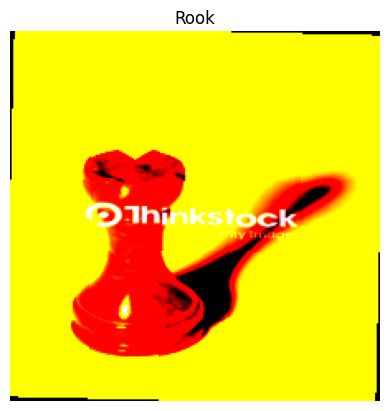

In [ ]:
import matplotlib.pyplot as plt

#batch pics
images,labels = next(iter(train_loader))
plt.imshow(images[0].permute(1,2,0))
plt.title(full_dataset.classes[labels[0]])
plt.axis("off")
plt.show()

In [ ]:
from torch import nn
import torch

class ChessBaselineModel(nn.Module):
    def __init__(self, input_shape: int, hidden_units:int, output_shape:int):
        super().__init__()

        #convolutional block
        self.conv_block = nn.Sequential(
            # layer 1
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, \
                      kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            #layer2
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, \
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*56*56, out_features=output_shape)
        )

    def forward(self,x):
        return self.classifier(self.conv_block(x))
    #set device
device = "cuda" if torch.cuda.is_available() else "cpu"

#start model 0
torch.manual_seed(42)
model_0 = ChessBaselineModel(input_shape=3, hidden_units=10, \
                             output_shape=len(full_dataset.classes)).to(device)

print(f"Model 0 Created on {device}")


Model 0 Created on cpu


In [ ]:
sample_X, sample_y = next(iter(train_loader))
sample_X =sample_X.to(device)
sample_pred = model_0(sample_X)
print(sample_pred.shape)

torch.Size([32, 6])


Interpretation: The output given illustrates that the batch of 32 pics are from the training data, then place them into the device and connects them through the model to forecast predictions. The 32 and 6 suggest that the model has a probability for every 6 classes for the 32 pictures. This is a quick way to crosscheck that the model is performing as it should.

## Model Training Setup ##

In [ ]:
loss_fn = nn.CrossEntropyLoss() #loss function
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001) #optimiser

#accuracy (percentages of the correct predictions)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc =(correct/len(y_pred))*100
    return acc

## Training and Validation Loop ##

In [ ]:
from tqdm.auto import tqdm #progess bar

epochs =10

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")

  #Training
  train_loss,train_acc = 0.0,0.0
  model_0.train()
  for batch, (X,y) in enumerate(train_loader):
    X, y = X.to(device), y.to(device)

    y_pred = model_0(X)
    loss = loss_fn(y_pred, y)

    train_loss += loss.item()
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_loader)
  train_acc /= len(train_loader)

  #Validation
  val_loss, val_acc = 0.0,0.0
  model_0.eval()
  with torch.no_grad():
    for X, y in val_loader:
      X, y = X.to(device), y.to(device)
      val_pred = model_0(X)
      loss = loss_fn(val_pred, y)

      val_loss += loss.item()
      val_acc += accuracy_fn(y_true=y, y_pred=val_pred.argmax(dim=1))

  val_loss /= len(val_loader)
  val_acc /= len(val_loader)

  print(f"Train Loss: {train_loss:4f} / Train Acc: {train_acc:2f}% / "
        f"Val Loss: {val_loss:.4f} / Val Acc: {val_acc:.2f}%")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Train Loss: 1.749698 / Train Acc: 25.053571% / Val Loss: 1.7513 / Val Acc: 18.28%
Epoch: 1
---------
Train Loss: 1.674227 / Train Acc: 33.785714% / Val Loss: 1.7573 / Val Acc: 18.18%
Epoch: 2
---------
Train Loss: 1.582353 / Train Acc: 34.366071% / Val Loss: 1.7352 / Val Acc: 25.42%
Epoch: 3
---------
Train Loss: 1.451886 / Train Acc: 43.964286% / Val Loss: 1.8032 / Val Acc: 24.43%
Epoch: 4
---------
Train Loss: 1.355869 / Train Acc: 47.687500% / Val Loss: 1.7563 / Val Acc: 32.45%
Epoch: 5
---------
Train Loss: 1.252182 / Train Acc: 53.330357% / Val Loss: 1.8378 / Val Acc: 37.24%
Epoch: 6
---------
Train Loss: 1.142266 / Train Acc: 58.526786% / Val Loss: 1.7856 / Val Acc: 35.47%
Epoch: 7
---------
Train Loss: 1.036159 / Train Acc: 61.366071% / Val Loss: 1.8125 / Val Acc: 32.45%
Epoch: 8
---------
Train Loss: 1.016241 / Train Acc: 62.160714% / Val Loss: 1.9081 / Val Acc: 30.68%
Epoch: 9
---------
Train Loss: 0.930364 / Train Acc: 67.741071% / Val Loss: 1.9336 / Val Ac

## Transfer Learning ##

In [ ]:
from torchvision import models

#load the pre trained Resnet18 model
model_1 = models.resnet18(weights="DEFAULT").to(device)

#freeze base leyers
for param in model_1.parameters():
  param.requires_grad = False

model_1.fc = nn.Linear(in_features=512, out_features=len(full_dataset.classes)).to(device)

#loss and optimiser
loss_fn = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(model_1.fc.parameters(), lr=0.0001)

print ("Model 1 is ready for training")

Model 1 is ready for training


In [ ]:
from tqdm.auto import tqdm

epochs =10

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")

  #Training
  train_loss,train_acc = 0.0,0.0
  model_1.train()
  for X, y in train_loader:
    X, y = X.to(device), y.to(device)
    y_pred = model_1(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    optimizer_1.zero_grad()
    loss.backward()
    optimizer_1.step()

  train_loss /= len(train_loader)
  train_acc /= len(train_loader)

  #Validation
  val_loss, val_acc = 0.0,0.0
  model_1.eval()
  with torch.inference_mode():
    for X, y in val_loader:
      X, y = X.to(device), y.to(device)
      val_pred = model_1(X)
      val_loss += loss_fn(val_pred, y).item()
      val_acc += accuracy_fn(y_true=y, y_pred=val_pred.argmax(dim=1))

  val_loss /= len(val_loader)
  val_acc /= len(val_loader)

  print(f"Model 1 - Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f}% | \
  Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f}%")


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Model 1 - Train loss: 1.5750 | Train acc: 42.65% |   Val loss: 1.6577 | Val acc: 31.67%
Epoch: 1
---------
Model 1 - Train loss: 1.5620 | Train acc: 43.22% |   Val loss: 1.6234 | Val acc: 37.24%
Epoch: 2
---------
Model 1 - Train loss: 1.5427 | Train acc: 40.29% |   Val loss: 1.5839 | Val acc: 44.48%
Epoch: 3
---------
Model 1 - Train loss: 1.5353 | Train acc: 43.32% |   Val loss: 1.5994 | Val acc: 36.56%
Epoch: 4
---------
Model 1 - Train loss: 1.5112 | Train acc: 44.82% |   Val loss: 1.5899 | Val acc: 41.46%
Epoch: 5
---------
Model 1 - Train loss: 1.4868 | Train acc: 46.58% |   Val loss: 1.5378 | Val acc: 41.25%
Epoch: 6
---------
Model 1 - Train loss: 1.4874 | Train acc: 48.36% |   Val loss: 1.5475 | Val acc: 39.58%
Epoch: 7
---------
Model 1 - Train loss: 1.4695 | Train acc: 48.10% |   Val loss: 1.5434 | Val acc: 40.47%
Epoch: 8
---------
Model 1 - Train loss: 1.4423 | Train acc: 51.22% |   Val loss: 1.5212 | Val acc: 47.14%
Epoch: 9
---------
Model 1 - Train lo

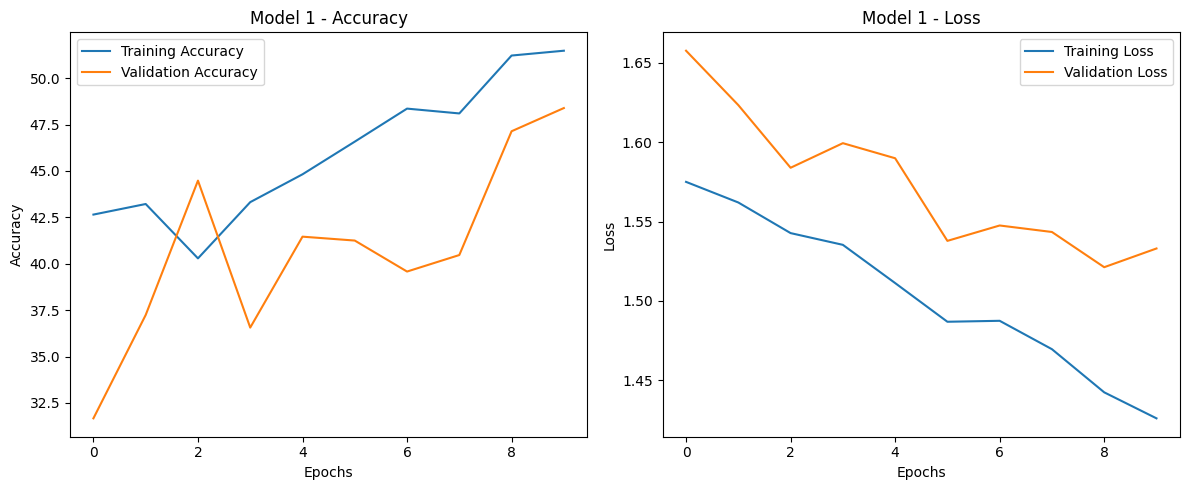

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(10)

train_acc_m1 = [42.65, 43.22, 40.29, 43.32, 44.82, 46.58, 48.36, 48.10, 51.22, 51.48]
val_acc_m1 = [31.67, 37.24, 44.48, 36.56, 41.46, 41.25, 39.58, 40.47, 47.14, 48.39]
train_loss_m1 = [1.5750, 1.5620, 1.5427, 1.5353, 1.5112, 1.4868, 1.4874, 1.4695, 1.4423, 1.4259]
val_loss_m1 = [1.6577, 1.6234, 1.5839, 1.5994, 1.5899, 1.5378, 1.5475, 1.5434, 1.5212, 1.5330]

plt.figure(figsize=(12,5))

#plot (accuracy)
plt.subplot(1,2,1)
plt.plot(epochs_range, train_acc_m1, label="Training Accuracy")
plt.plot(epochs_range, val_acc_m1, label="Validation Accuracy")
plt.title("Model 1 - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

#plot (loss)
plt.subplot(1,2,2)
plt.plot(epochs_range, train_loss_m1, label="Training Loss")
plt.plot(epochs_range, val_loss_m1, label="Validation Loss")
plt.title("Model 1 - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout ()
plt.show()

## Confusion Matrix for Model  - ResNet 18 ##

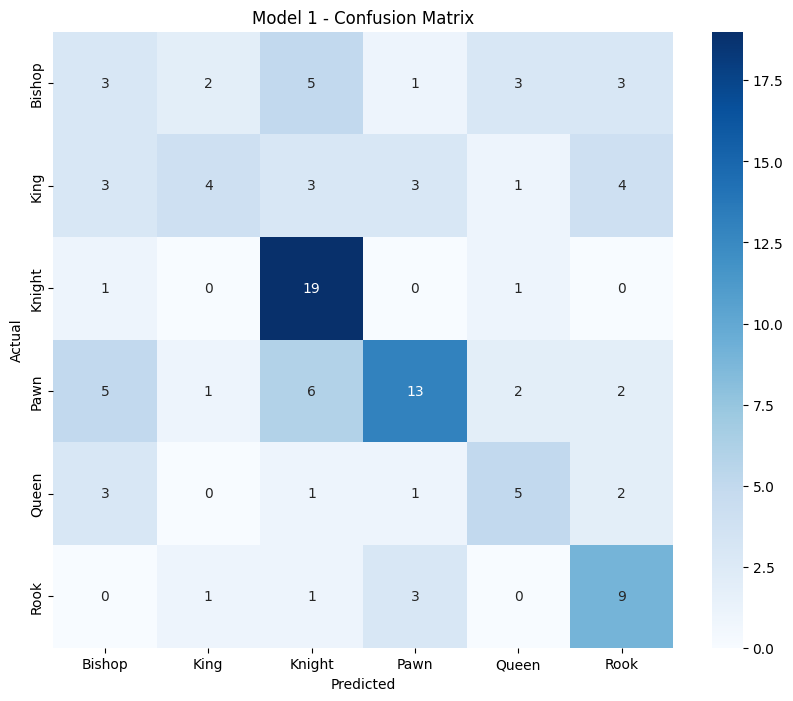

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_pred = []
all_labels = []

model_1.eval()
with torch.inference_mode():
  for X, y in val_loader:
      X, y = X.to(device), y.to(device)
      outputs = model_1(X)
      preds = torch.argmax(outputs, dim=1)
      all_pred.extend(preds.cpu().numpy())
      all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt = "d", cmap="Blues",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 1 - Confusion Matrix")
plt.show()